# 🐯 TIGeR Kaggle Workflow
Welcome to the complete TIGeR (Text-Image Generative Repair) pipeline.

This notebook is broken down step-by-step so you can see exactly how the AI identifies, routes, and repairs multimodal errors in ecommerce catalogues.


## 📖 Glossary of Terms & Jargon

Before we begin, here is a quick guide to the terminology used in this pipeline:

* **TIGeR**: Text-Image Generative Repair (the name of this system).
* **V2T (Vision-to-Text)**: A repair strategy where we *fix the text* to match the image (e.g., updating the description to say "red shirt" instead of "blue shirt" because the image is clearly red).
* **T2V (Text-to-Vision)**: A repair strategy where we *replace the image* because the text description is correct, but the wrong photo was uploaded.
* **Sieve (Error Detection)**: The initial scanner that looks at the whole catalogue and flags products where the image and text do not seem to match.
* **Arbiter (Routing)**: The AI decision-maker. It looks at the flagged products and decides the safest way to fix them (V2T vs. T2V vs. Escalate to Human).
* **Solver (Repair Execution)**: The system that carries out the Arbiter's instructions (applying text patches or swapping images).
* **VLM Judge (Vision-Language Model)**: An advanced AI (like Google Gemini) that acts as a final safety checkpoint. It looks at the repaired product and vetoes the repair if it doesn't make sense.
* **Generative Fallback**: If the Arbiter wants to replace an image (T2V) but cannot find a valid replacement in the catalogue, the system uses Stable Diffusion to synthetically generate a brand new, mathematically perfect image from scratch.
* **LOO (Leave-One-Out) Masking**: A detective technique used by the system to figure out what is wrong. It hides one word at a time from the text to see if the image-text match improves, allowing it to pinpoint the exact wrong word.



### Step 0: Clone the Repository
First, we download the latest code from GitHub and set up our working directory.


In [1]:
!rm -rf TIGeR-Text-Image-Generative-Repair
!git clone https://github.com/namaray/TIGeR-Text-Image-Generative-Repair.git
%cd TIGeR-Text-Image-Generative-Repair
!pip install -e ".[dev,vlm,gen]" -q

Cloning into 'TIGeR-Text-Image-Generative-Repair'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (600/600), done.
remote: Compressing objects: 100% (439/439), done.
remote: Total 600 (delta 185), reused 558 (delta 144), pack-reused 0 (from 0)
Receiving objects: 100% (600/600), 2.64 MiB | 31.06 MiB/s, done.
Resolving deltas: 100% (185/185), done.
/kaggle/working/TIGeR-Text-Image-Generative-Repair
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiger (pyproject.toml) ... done


### Step 1: Environment Setup
We load the Gemini API key from Kaggle Secrets so our VLM Judge can verify complex repairs.


In [2]:
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    gemini_key = user_secrets.get_secret("gemini api")
    os.environ["GEMINI_API_KEY"] = gemini_key
    print("✅ Gemini API Key loaded successfully from Kaggle Secrets!")
except Exception as e:
    print("❌ Failed to load Gemini API Key. Did you add it to Kaggle Secrets? Error:", e)

✅ Gemini API Key loaded successfully from Kaggle Secrets!


## Phase 1: Data Generation
### Step 2: Generate Synthetic Catalogue (`synthgen`)
Here we create a perfectly clean, ground-truth catalogue of synthetic products (shirts, shoes, bags, hats) and render their images. We also explicitly inject a highly unique item (a magenta velvet spacesuit) to guarantee a generative fallback scenario later.


In [3]:
!python -m tiger.cli synthgen

generated 241 products -> data/sample/products.parquet
category  split      
bags      calibration    25
          report         35
hats      calibration    29
          report         31
shirts    calibration    32
          report         29
shoes     calibration    33
          report         27


## Phase 2: AI Calibration
### Step 3: Calibrate Sieve Thresholds (`calibrate`)
The system analyzes the clean data to learn what "normal" similarity scores look like for different product categories, setting automatic thresholds for error detection.


In [4]:
!python -m tiger.cli calibrate

tokenizer_config.json: 100%|███████████████████| 592/592 [00:00<00:00, 3.43MB/s]
vocab.json: 862kB [00:00, 102MB/s]
merges.txt: 525kB [00:00, 109MB/s]
tokenizer.json: 2.22MB [00:00, 157MB/s]
special_tokens_map.json: 100%|█████████████████| 389/389 [00:00<00:00, 2.04MB/s]
config.json: 4.19kB [00:00, 16.4MB/s]
pytorch_model.bin: 100%|██████████████████████| 605M/605M [00:04<00:00, 150MB/s]
model.safetensors:   0%|                             | 0.00/605M [00:00<?, ?B/s]
Loading weights:   0%|                                  | 0/398 [00:00<?, ?it/s]
Loading weights:   0%| | 1/398 [00:00<00:00, 2504.06it/s, Materializing param=lo
Loading weights:   0%| | 1/398 [00:00<00:01, 328.58it/s, Materializing param=log
Loading weights:   1%| | 2/398 [00:00<00:01, 221.47it/s, Materializing param=tex
Loading weights:   1%| | 2/398 [00:00<00:02, 179.72it/s, Materializing param=tex
Loading weights:   1%| | 3/398 [00:00<00:01, 212.01it/s, Materializing param=tex
Loading weights:   1%| | 3/398 [00:00<00:0

### Step 4: Train the AI Arbiter (`train-arbiter`)
We train a lightweight gradient boosting model (XGBoost) to act as the AI Arbiter. This model learns to look at error evidence and decide the safest repair strategy (e.g., Fix Text, Replace Image, or Escalate to Human).


In [5]:
!python -m tiger.cli train-arbiter

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_cal_seed1007.parquet
{
  "seed": 1007,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 119,
  "rows_noisy": 34,
  "by_label": {
    "clean": 85,
    "swap_image": 16,
    "mutate_text": 15,
    "mixed": 2,
    "missing_image": 1
  },
  "by_subtype": {
    "swap_image": 12,
    "color_flip": 7,
    "swap_image_same_category": 4,
    "material_flip": 2,
    "attribute_drop": 2,
    "near_color_flip": 2,
    "title_contradiction": 2,
    "mixed_swap_color": 2,
    "missing_image": 1
  },
  "self_verified": true
}
Loading weights: 100%|█| 398/398 [00:00<00:00, 2698.81it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-pa

### Step 5: Calibrate Decision Fusion (`calibrate-fusion`)
We tune the confidence gating of the Arbiter to ensure it hits a strict 85% precision floor, meaning it only automatically repairs items when it is highly confident.


In [6]:
!python -m tiger.cli calibrate-fusion

precision floor 0.85; calibrated on 952 labelled rows
  flag_probe_color           precision=0.91 fired=144 z>=2.5
  flag_probe_material        precision=1.0 fired=5 z>=2.5
  flag_probe_pattern         precision=0.918 fired=73 z>=2.5
  flag_low_sim               precision=0.835 fired=170
  flag_text_out_of_domain    precision=1.0 fired=16
  flag_title_contradiction   precision=1.0 fired=16
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_fusion.json


## Phase 3: The Repair Pipeline
### Step 6: Inject Anomalies (`noise`)
Now we intentionally corrupt the clean catalogue! We drop images, swap images with other products, and mutate text attributes to simulate real-world e-commerce errors.


In [7]:
!python -m tiger.cli noise --seed 7

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 122,
  "rows_noisy": 34,
  "by_label": {
    "clean": 88,
    "swap_image": 15,
    "mutate_text": 15,
    "missing_image": 2,
    "mixed": 2
  },
  "by_subtype": {
    "swap_image": 11,
    "color_flip": 7,
    "swap_image_same_category": 4,
    "near_color_flip": 2,
    "missing_image": 2,
    "mixed_swap_color": 2,
    "title_contradiction": 2,
    "material_flip": 2,
    "attribute_drop": 2
  },
  "self_verified": true
}


### Step 7: Error Detection (`detect`)
The Sieve scans the corrupted catalogue and flags suspicious products that fail our calibrated similarity checks.


In [8]:
!python -m tiger.cli detect --seed 7

Loading weights: 100%|█| 398/398 [00:00<00:00, 2754.52it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Stage 1: Error Detection Complete
--------------------------------------------------
Out of 122 products scanned, we flagged 39 suspicious items.

Reasons for flagging:
- 83 items: ok
- 19 items: low_sim
- 12 items: probe_color
- 2 items: missing_image
- 2 items: title_contradiction
- 2 items: text_out_of_domain
- 2 items: probe_pattern

(Raw data saved to /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/sieve_seed7.parquet)


### Step 8: Evidence Gathering (`analyze`)
For every flagged item, we gather deep evidence (leave-one-out masking, attribute probing) to figure out exactly *what* went wrong.


In [9]:
!python -m tiger.cli analyze --seed 7

Loading weights: 100%|█| 398/398 [00:00<00:00, 3334.44it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/evidence_seed7.jsonl (39 evidence records)


### Step 9: Routing Decisions (`route`)
The AI Arbiter reviews the evidence and decides how to fix each item (Fix Text vs. Replace Image).


In [10]:
!python -m tiger.cli route --seed 7



🚦 Stage 3: Routing Decisions
--------------------------------------------------
The AI Arbiter analyzed the evidence for the flagged items and assigned repair strategies:
- [v2t_patch]                  12 items
- 🧑‍💻 Escalate to Human        12 items
- [t2v_replace_image]          5 items
- [t2v_replace_image_then_v2t] 4 items
- ✅ Dismiss as False Positive  4 items
- [acquire_image]              2 items

(Raw plan saved to /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/route_plan_seed7.csv)


### Step 10: Closed-Loop Repair (`repair`)
The Solver executes the Arbiter's plan. It attempts the fixes, asks the Gemini VLM Judge to verify them, and synthesizes brand new images via Stable Diffusion if no image exists in the catalogue.


In [11]:
!python -m tiger.cli repair --seed 7 --vlm-judge --generative-fallback


VLM judge: gemini-3.5-flash-lite (Gemini)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading Generative Fallback Model: runwayml/stable-diffusion-v1-5 (quiet mode)...
Loading pipeline components...: 100%|█████████████| 6/6 [00:01<00:00,  4.32it/s]
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='NO' -> False
[GeminiVLMJudge] raw='NO' -> False
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='NO' -> False
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='NO' -> False
[GeminiVLMJudge] raw='NO' -> False
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[Gemini

## Phase 4: Outputs & Visualization
### Step 11: Export Data
Zip the outputs so you can download the repaired data and logs.


In [12]:
!zip -r /kaggle/working/tiger_outputs.zip data/outputs data/thresholds data/processed
print("✅ Download tiger_outputs.zip from the '/kaggle/working' directory in the right sidebar!")

  adding: data/outputs/ (stored 0%)
  adding: data/outputs/sieve_cal_seed1007_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1011.jsonl (deflated 82%)
  adding: data/outputs/evidence_cal_seed1014.jsonl (deflated 82%)
  adding: data/outputs/sieve_cal_seed1008.parquet (deflated 53%)
  adding: data/outputs/sieve_cal_seed1013_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1014_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_seed7.jsonl (deflated 81%)
  adding: data/outputs/sieve_cal_seed1008_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1014.parquet (deflated 52%)
  adding: data/outputs/evidence_cal_seed1012.jsonl (deflated 81%)
  adding: data/outputs/sieve_cal_seed1011.parquet (deflated 53%)
  adding: data/outputs/sieve_cal_seed1012_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_seed7_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1010.jsonl (deflated 82%)
  adding: data/outputs/evidence_cal_seed1013.jsonl 

### Step 12: Visual Inspection Grid
Let's see the results! This cell plots a grid showing the original clean state, the corrupted state, and the final AI-repaired state. **Note: The forced Generative Fallback (the magenta spacesuit) is guaranteed to appear here!**


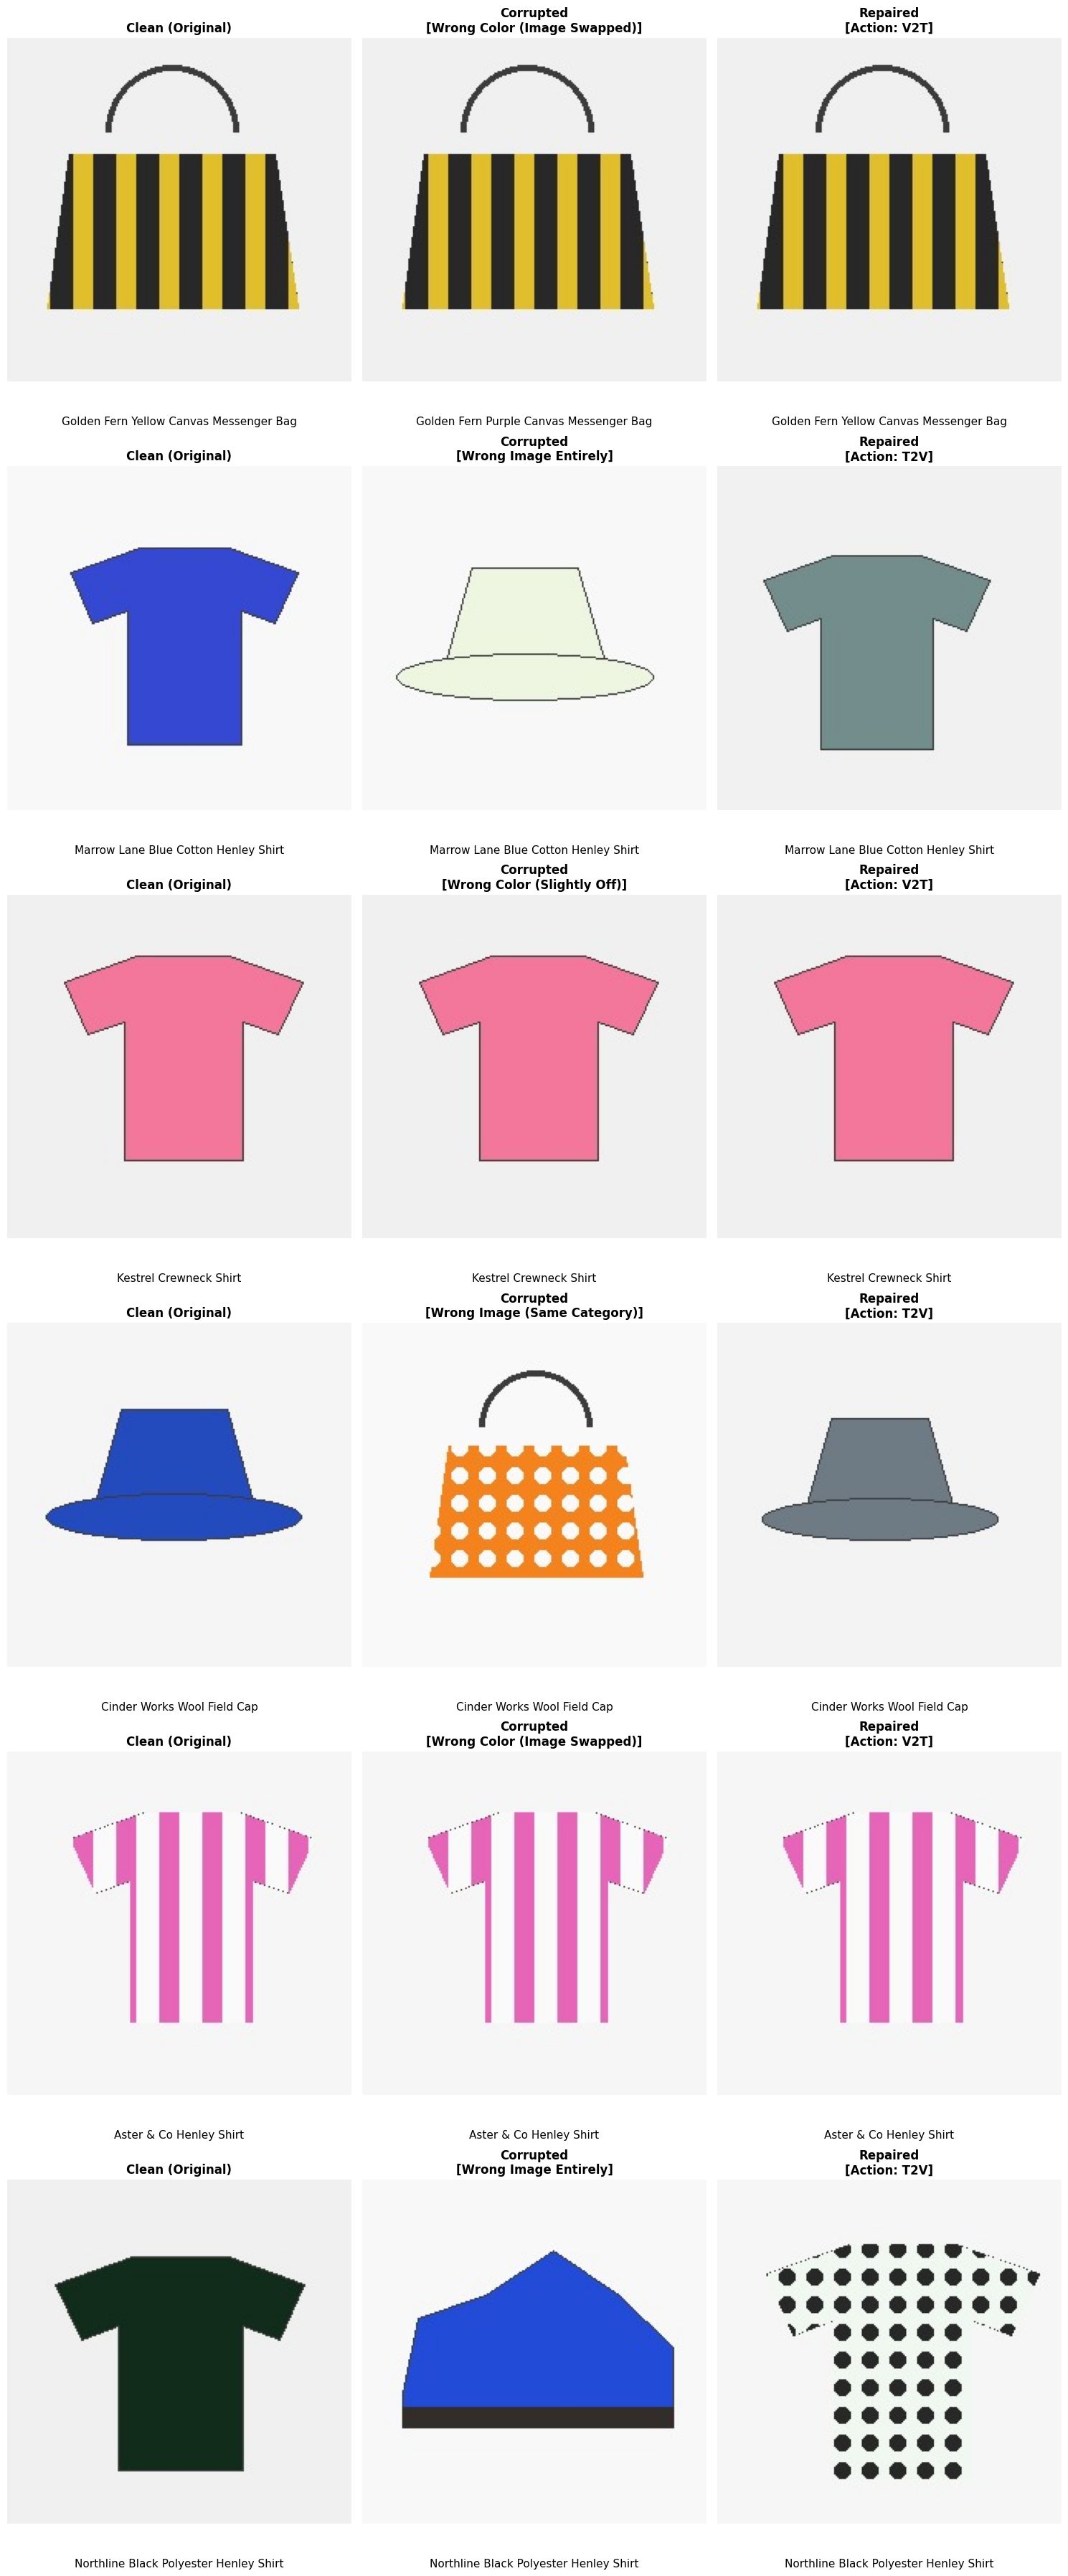

In [13]:
# Visual Inspection: See the Clean -> Corrupted -> Repaired progression
from tiger.viz import plot_repair_stages
plot_repair_stages(seed=7)


### Step 14: Generative Fallback Demo — Before & After
This cell directly demonstrates the **Generative Fallback** component of TIGeR.

We pick a real product from the clean catalogue, delete its image (simulating a `missing_image` error),
then ask Stable Diffusion to **generate a brand new image** from the product's text description.

The result is displayed as a 3-column grid: **Original → Corrupted → AI-Generated Replacement**.


In [ ]:
# 🎨 Generative Fallback Demo: Original → Corrupted → AI-Generated
import os, warnings
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Load a product from the clean catalogue
df = pd.read_parquet('data/sample/products.parquet')
# Pick one that has a clear, descriptive title
product = df[df['category'] == 'shirts'].iloc[3]
clean_img_path = Path(product['image_path'])
caption = product['canonical_text']
title = product['title']

print(f'Product: {title}')
print(f'Caption for generation: {caption}')
print()

# 2. Generate a replacement image using Stable Diffusion
from tiger.generator import StableDiffusionGenerator
gen = StableDiffusionGenerator(device='cuda')
gen_path = Path('data/outputs/gen_demo.jpg')
gen.generate(caption, gen_path)
print('✅ Image generated successfully!')
print()

# 3. Plot the 3-column grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Column 1: Clean original
if clean_img_path.exists():
    axes[0].imshow(Image.open(clean_img_path))
else:
    axes[0].text(0.5, 0.5, 'Image Not Found', ha='center', va='center', fontsize=14)
axes[0].set_title('✅ Original (Clean)', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')

# Column 2: Corrupted (missing image)
axes[1].set_facecolor('#1a1a2e')
axes[1].text(0.5, 0.5, '❌ IMAGE DELETED\n\nThis product\'s photo was\ndeleted from the database.\n\nThe AI must generate\na replacement from text alone.',
             ha='center', va='center', fontsize=11, color='#e94560', fontweight='bold',
             transform=axes[1].transAxes, linespacing=1.6)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_title('❌ Corrupted (Image Missing)', fontsize=14, fontweight='bold', color='red')
axes[1].axis('off')

# Column 3: AI-Generated replacement
axes[2].imshow(Image.open(gen_path))
axes[2].set_title('🤖 AI-Generated Replacement', fontsize=14, fontweight='bold', color='#0f3460')
axes[2].axis('off')

# Title text below
fig.suptitle(f'Generative Fallback Demo: \"{title}\"', fontsize=16, fontweight='bold', y=0.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('data/outputs/generative_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved to data/outputs/generative_demo.png')
